# 02 - Pré-processamento de Dados
## Tech Challenge Fase 1 - Saúde e Segurança da Mulher
**Responsável:** Natalia Cabrera

---

### Objetivo
Aplicar o pipeline de pré-processamento nos dados, preparando-os para a modelagem de Machine Learning.

In [2]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.append('../..')

from src.data_loader import load_breast_cancer_dataset
from src.preprocessing import (
    check_data_quality,
    handle_missing_values,
    encode_categorical,
    scale_features,
    split_data,
    full_preprocessing_pipeline
)

%matplotlib inline

## 1. Carregamento e Verificação de Qualidade

In [3]:
# Carregar dados
df = load_breast_cancer_dataset()

# Verificar qualidade
quality_report = check_data_quality(df)

Dataset carregado do sklearn.datasets
Shape: (569, 32)
Colunas: ['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness', 'mean compactness', 'mean concavity', 'mean concave points', 'mean symmetry', 'mean fractal dimension', 'radius error', 'texture error', 'perimeter error', 'area error', 'smoothness error', 'compactness error', 'concavity error', 'concave points error', 'symmetry error', 'fractal dimension error', 'worst radius', 'worst texture', 'worst perimeter', 'worst area', 'worst smoothness', 'worst compactness', 'worst concavity', 'worst concave points', 'worst symmetry', 'worst fractal dimension', 'target', 'diagnosis']
RELATÓRIO DE QUALIDADE DOS DADOS
Total de registros: 569
Total de features: 32
Duplicatas: 0
Total de valores nulos: 0


## 2. Pipeline Completo de Pré-processamento

In [4]:
# Executar pipeline completo
pipeline_result = full_preprocessing_pipeline(
    df,
    target_col='target',
    drop_cols=['diagnosis'],  # Remover coluna textual redundante
    test_size=0.2
)

X_train = pipeline_result['X_train']
X_test = pipeline_result['X_test']
y_train = pipeline_result['y_train']
y_test = pipeline_result['y_test']
feature_names = pipeline_result['feature_names']


PIPELINE DE PRÉ-PROCESSAMENTO

1. Colunas removidas: ['diagnosis']

2. Tratamento de valores ausentes:
Valores nulos restantes: 0

3. Codificação de variáveis categóricas:

4. Features: 30 | Target: 'target'

5. Padronização:
Features padronizadas com standardScaler

6. Separação treino/teste:
Dados separados:
  Treino: 455 amostras (80%)
  Teste:  114 amostras (20%)
  Distribuição no treino: {1: 285, 0: 170}
  Distribuição no teste:  {1: 72, 0: 42}

PIPELINE CONCLUÍDO COM SUCESSO!


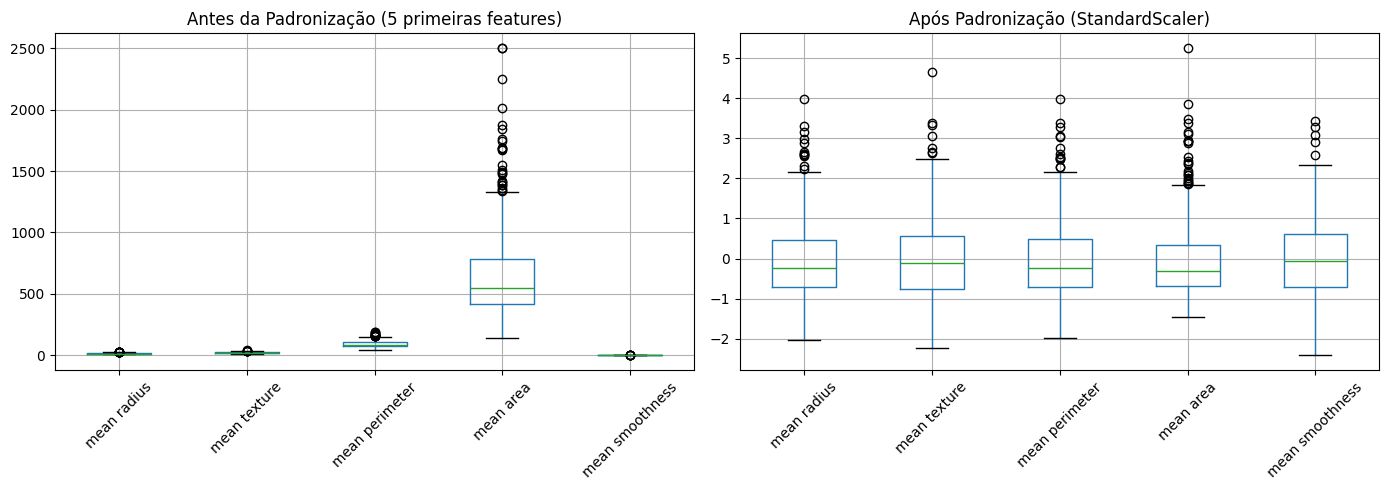

In [6]:
# Verificar distribuições após padronização
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Antes (primeiras 5 features originais)
df[feature_names[:5]].boxplot(ax=axes[0])
axes[0].set_title('Antes da Padronização (5 primeiras features)')
axes[0].tick_params(axis='x', rotation=45)

# Depois
X_train[feature_names[:5]].boxplot(ax=axes[1])
axes[1].set_title('Após Padronização (StandardScaler)')
axes[1].tick_params(axis='x', rotation=45)

import os
# Garantir que o diretório de figuras exista (caminho relativo ao notebook)
os.makedirs('../../reports/figures', exist_ok=True)
plt.tight_layout()
plt.savefig('../../reports/figures/padronizacao_comparacao.png', dpi=150)
plt.show()

In [7]:
# Salvar dados processados
import os
# Garantir que o diretório de dados processados exista (caminho relativo ao notebook)
os.makedirs('../../data/processed', exist_ok=True)
X_train.to_csv('../../data/processed/X_train.csv', index=False)
X_test.to_csv('../../data/processed/X_test.csv', index=False)
y_train.to_csv('../../data/processed/y_train.csv', index=False)
y_test.to_csv('../../data/processed/y_test.csv', index=False)

print("Dados processados salvos em data/processed/")

Dados processados salvos em data/processed/


## 3. Resumo do Pré-processamento

**Resumo aplicado pelo pipeline `full_preprocessing_pipeline`**

| Etapa | Decisão tomada | Justificativa |
|---|---|---|
| Valores ausentes | Nenhum (0 valores faltantes) | Dataset originalmente limpo; não foi necessária imputação |
| Codificação | `diagnosis` removido; target usado: `target` (numérico) | `target` já presente no dataset; evita duplicidade textual |
| Padronização | `StandardScaler` aplicado às features numéricas | Recomendado para modelos sensíveis à escala (SVM, LR, NN); preserva relação entre variáveis |
| Split | 80/20 estratificado (train/test) | Mantém proporção das classes entre conjuntos para validação robusta |
| Colunas removidas | `diagnosis` (removida conforme parâmetro `drop_cols`) | Remove redundância com `target`; nenhuma outra coluna foi removida automaticamente |

**Observações**: Os conjuntos resultantes estão em `X_train`, `X_test`, `y_train`, `y_test`. Arquivos gerados: figuras em `reports/figures` e CSVs em `data/processed`.

*(Atualize esta seção se executar remoções adicionais por correlação/VIF/PCA)*